In [191]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [192]:
df = pd.read_csv("Employers_data.csv")


In [ ]:
df.columns

Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title',
       'Experience_Years', 'Education_Level', 'Location', 'Salary'],
      dtype='object')

In [193]:
df["Job_Title"].unique()


array(['Engineer', 'Executive', 'Intern', 'Analyst', 'Manager'],
      dtype=object)

In [194]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.copy()


df_encoded['Job_Title_Encoded'] = le.fit_transform(df['Job_Title'])
model = LinearRegression()
model.fit(df_encoded[['Job_Title_Encoded', 'Experience_Years']], df_encoded['Salary'])

print("Model trained successfully!")

Model trained successfully!


In [196]:
import sys
print(sys.version)


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


Model Parameters

In [ ]:
model.coef_[0]

np.float64(3057.576172595657)

In [ ]:
model.intercept_

np.float64(56253.331455670734)

In [ ]:
mean_squared_error(df_encoded['Salary'], model.predict(df_encoded[['Job_Title_Encoded', 'Experience_Years']]))

390899639.5084981

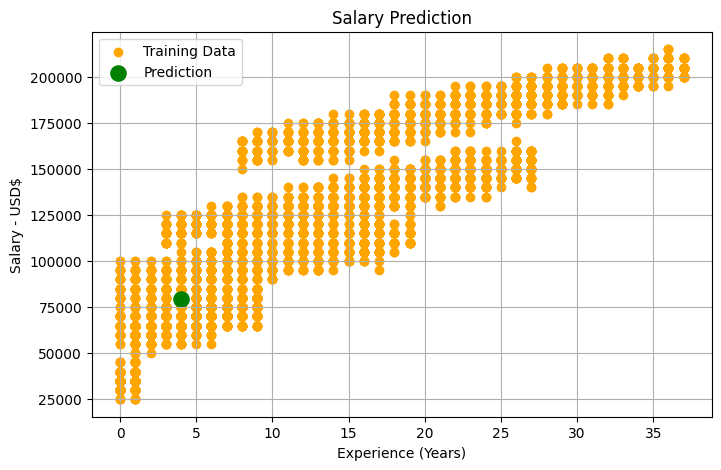

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_encoded["Experience_Years"],
    df_encoded["Salary"],
    color="orange",
    label="Training Data"
)

plt.scatter(
    experience,
    salary_pred[0],
    color="green",
    s=120,
    label="Prediction"
)

plt.xlabel("Experience (Years)")
plt.ylabel("Salary - USD$")
plt.title("Salary Prediction")
plt.legend()
plt.grid(True)

plt.show()

In [198]:
def getJobAndExp():
    print("Job List\n")

    job_titles = df["Job_Title"].unique()

    for index, job in enumerate(job_titles):
        print(f"{index}: {job}")

    job_index = int(input("Enter Job Title Index: "))
    experience = float(input("Enter Experience: "))
    return job_index, experience

while True:

    job_index, experience = getJobAndExp()

    job_titles = df["Job_Title"].unique()

    selected_job = job_titles[job_index]

    job_title_encoded = le.transform([selected_job])[0]

    new_data = pd.DataFrame({
        "Job_Title_Encoded": [job_title_encoded],
        "Experience_Years": [experience]
    })

    salary_pred = model.predict(new_data)

    print(
        f"Predicted Salary of {selected_job} having "
        f"{experience} Years of Experience is : "
        f"${salary_pred[0]:,.2f}"
    )

    choice = input("\nPredict another salary? (y/n): ")

    if choice.lower() != "y":
        print("Goodbye!")
        break


Job List

0: Engineer
1: Executive
2: Intern
3: Analyst
4: Manager
Enter Job Title Index: 0
Enter Experience: 5
Predicted Salary of Engineer having 5.0 Years of Experience is : $80,705.65

Predict another salary? (y/n): N
Goodbye!


Visualizations

In [197]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Files saved successfully: salary_prediction_model.pkl and label_encoder.pkl")

Files saved successfully: salary_prediction_model.pkl and label_encoder.pkl
